In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm.notebook import tqdm

from shapely.geometry import Point
from shapely.geometry.polygon import Polygon

In [6]:
def rainbow_text(fig, ax, x, y, ls, lc, **kw):
  from matplotlib import transforms
  """
  Take a list of strings ``ls`` and colors ``lc`` and place them next to each
  other, with text ls[i] being shown in color lc[i].

  This example shows how to do both vertical and horizontal text, and will
  pass all keyword arguments to plt.text, so you can set the font size,
  family, etc.
  """
  t = ax.transData
  #horizontal version
  for s, c in zip(ls, lc):
    text = ax.text(x, y, s + " ", color=c, transform=t, **kw)
    text.draw(fig.canvas.get_renderer())
    ex = text.get_window_extent()
    x += 1
    t = transforms.offset_copy(text._transform, x = ex.width, units = 'dots')

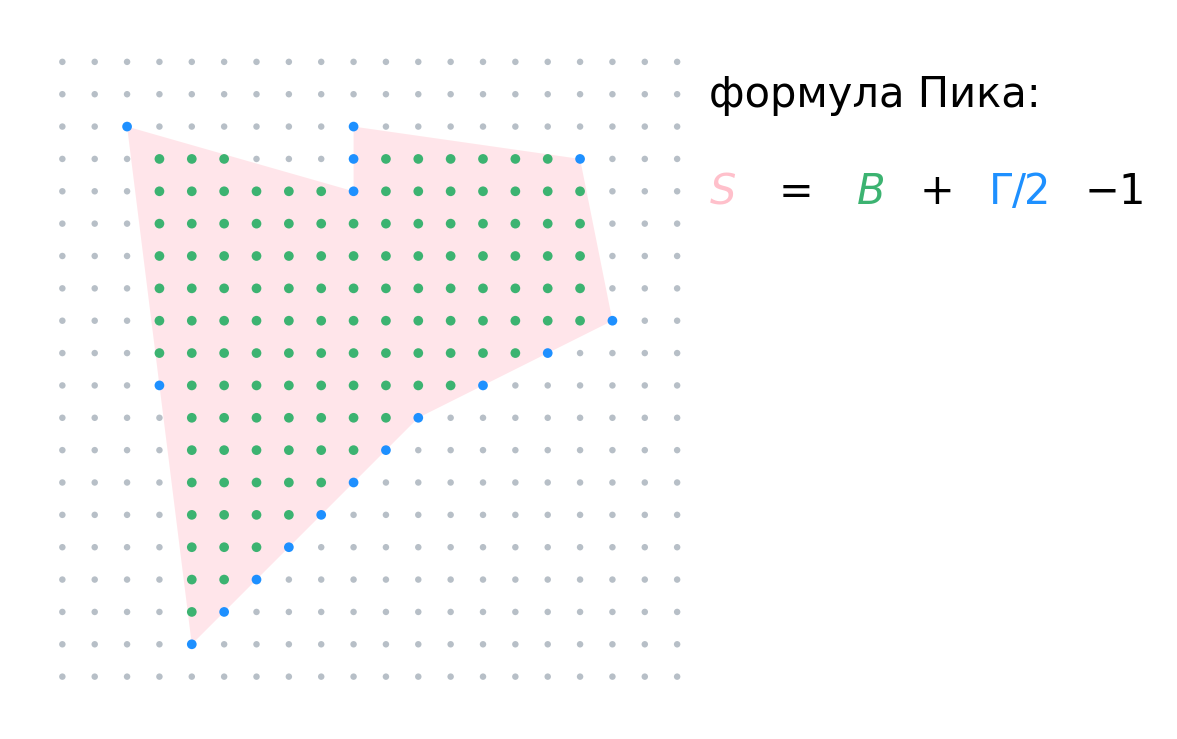

In [39]:
fig, ax = plt.subplots(figsize=(5, 3), dpi=300, facecolor=(1,1,1))

xi = np.arange(20)
yi = np.arange(20)

xs = [16, 17, 11, 4, 2, 9, 9, 16]
ys = [16, 11, 8, 1, 17, 15, 17, 16]

xx, yy = np.meshgrid(xi, yi)
points = np.array([xx.flatten(), yy.flatten()]).T
polygon = np.array([xs, ys]).T
ax.add_artist(mpl.patches.Polygon(polygon, ec=None, fc='pink', alpha=0.4))
polygon = Polygon(polygon)

for x, y in points:
  if polygon.contains(Point(x, y)):
    ax.add_artist(mpl.patches.Circle((x, y), 0.15, edgecolor=None, fc='mediumseagreen'))
  elif polygon.intersects(Point(x, y)):
    ax.add_artist(mpl.patches.Circle((x, y), 0.15, edgecolor=None, fc='dodgerblue'))
  else:
    ax.add_artist(mpl.patches.Circle((x, y), 0.1, edgecolor=None, fc='slategrey', alpha=0.5))

ax.set_xlim(-1, len(xi))
ax.set_ylim(-1, len(yi))
ax.set_aspect(1);
ax.axis("off");

# ax.text(20, 18, r"$\Lambda = B + \Gamma/2 - 1$", ha='left', va='center')

# plt.figure()
ax.text(20, 18, "формула Пика:", ha='left', va='center')
rainbow_text(fig, ax, 20, 15, [r"$S$", r"$=$", r"$B$", r"$+$", r'$\Gamma/2$', r"$-1$"], 
        ['pink', 'k', 'mediumseagreen', 'k', 'dodgerblue', 'k'], ha='left', va='center')

In [20]:
for step, rad in enumerate(tqdm(np.linspace(0, 1.5, 240))):
  fig, ax = plt.subplots(figsize=(4, 4), dpi=150)

  xi = np.arange(20)
  yi = np.arange(20)

  for x in xi:
    for y in yi:
      ax.add_artist(mpl.patches.Circle((x, y), 0.1, ec=None, fc='k'))

  for x in xi:
    for y in yi:
      ax.add_artist(mpl.patches.Circle((x, y), rad, ec=None, fc='royalblue', zorder=-1))


  ax.set_xlim(-1, len(xi))
  ax.set_ylim(-1, len(yi))
  ax.set_aspect(1);
  ax.axis("off");
  plt.savefig(f"lattice/st{step:03}.png")
  plt.close()

  0%|          | 0/240 [00:00<?, ?it/s]